In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

In [12]:
df = pd.read_csv('KAGGLE_RESULTS_FIX/UNIVARIATE/24h/results/LSTM_yj_denormalized.csv')
data = df.sort_values(by='MAPE_OF_THIS_DATA_POINT').reset_index(drop=True)
data

,DATE_OF_DATA_POINT,LAG_DATA_SCALED,ACTUAL_VALUE_HORIZON_DENORM,PREDICTED_VALUE_HORIZON_DENORM,MAPE_OF_THIS_DATA_POINT
0,2020-01-20 22:00:00+00:00,"[np.float64(0.6378341059276063), np.float64(0....","[np.float64(7705.000000000001), np.float64(744...","[np.float64(7662.243904054166), np.float64(740...",0.599072
1,2020-02-11 20:00:00+00:00,"[np.float64(0.7038169444718414), np.float64(0....","[np.float64(7851.0), np.float64(7656.000000000...","[np.float64(8000.949345827104), np.float64(764...",0.646808
2,2020-08-11 00:00:00+00:00,"[np.float64(0.3854423513166979), np.float64(0....","[np.float64(4917.0), np.float64(4800.0), np.fl...","[np.float64(4883.386283934116), np.float64(471...",0.678706
3,2020-08-27 02:00:00+00:00,"[np.float64(0.42992405562678765), np.float64(0...","[np.float64(5084.0), np.float64(5563.999999999...","[np.float64(5210.307865917684), np.float64(555...",0.705566
4,2020-08-19 01:00:00+00:00,"[np.float64(0.4049709044284446), np.float64(0....","[np.float64(4918.0), np.float64(5019.0), np.fl...","[np.float64(4987.701151669025), np.float64(499...",0.708529
...,...,...,...,...,...
10052,2020-04-25 18:00:00+00:00,"[np.float64(0.5730348160568104), np.float64(0....","[np.float64(5919.000000000001), np.float64(557...","[np.float64(5890.211012542249), np.float64(585...",35.724623
10053,2020-04-11 21:00:00+00:00,"[np.float64(0.4580333366209685), np.float64(0....","[np.float64(4958.0), np.float64(4655.0), np.fl...","[np.float64(5131.399698495866), np.float64(488...",37.069742
10054,2020-04-25 19:00:00+00:00,"[np.float64(0.5364434362363153), np.float64(0....","[np.float64(5578.999999999999), np.float64(547...","[np.float64(5963.438463926316), np.float64(585...",38.316429
10055,2020-04-11 20:00:00+00:00,"[np.float64(0.4972877009567018), np.float64(0....","[np.float64(5349.0), np.float64(4958.0), np.fl...","[np.float64(5461.372248023749), np.float64(530...",40.233908


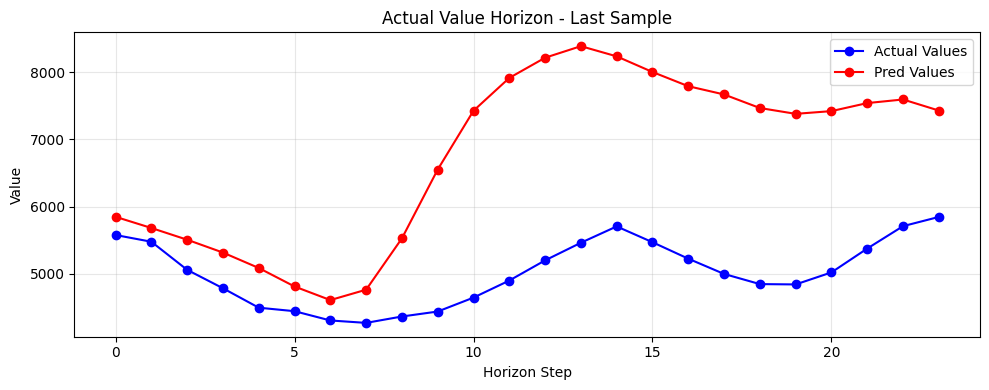

In [4]:
def parse_array_string(s):
    if not isinstance(s, str):
        return s
    s_clean = re.sub(r'np\.float\d+\(', '', s)
    s_clean = s_clean.replace(')', '')
    s_clean = s_clean.strip('[]')
    s_clean = re.sub(r'[,]+', ' ', s_clean)
    s_clean = re.sub(r'\s+', ' ', s_clean).strip()
    if not s_clean:
        return []
    return [float(x) for x in s_clean.split(' ')]

actual_value_str = data['DENORM_ACTUAL_VALUE_HORIZON'].iloc[-1]
actual_value_list = parse_array_string(actual_value_str)

pred_val = data['DENORM_PREDICTED_VALUE_HORIZON'].iloc[-1]

predicted_value_list = parse_array_string(pred_val)

plt.figure(figsize=(10, 4))
plt.plot(actual_value_list, marker='o', color='blue', label='Actual Values')

plt.plot(predicted_value_list, marker='o', color='red', label='Pred Values')
plt.title('Actual Value Horizon - Last Sample')
plt.xlabel('Horizon Step')
plt.ylabel('Value')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

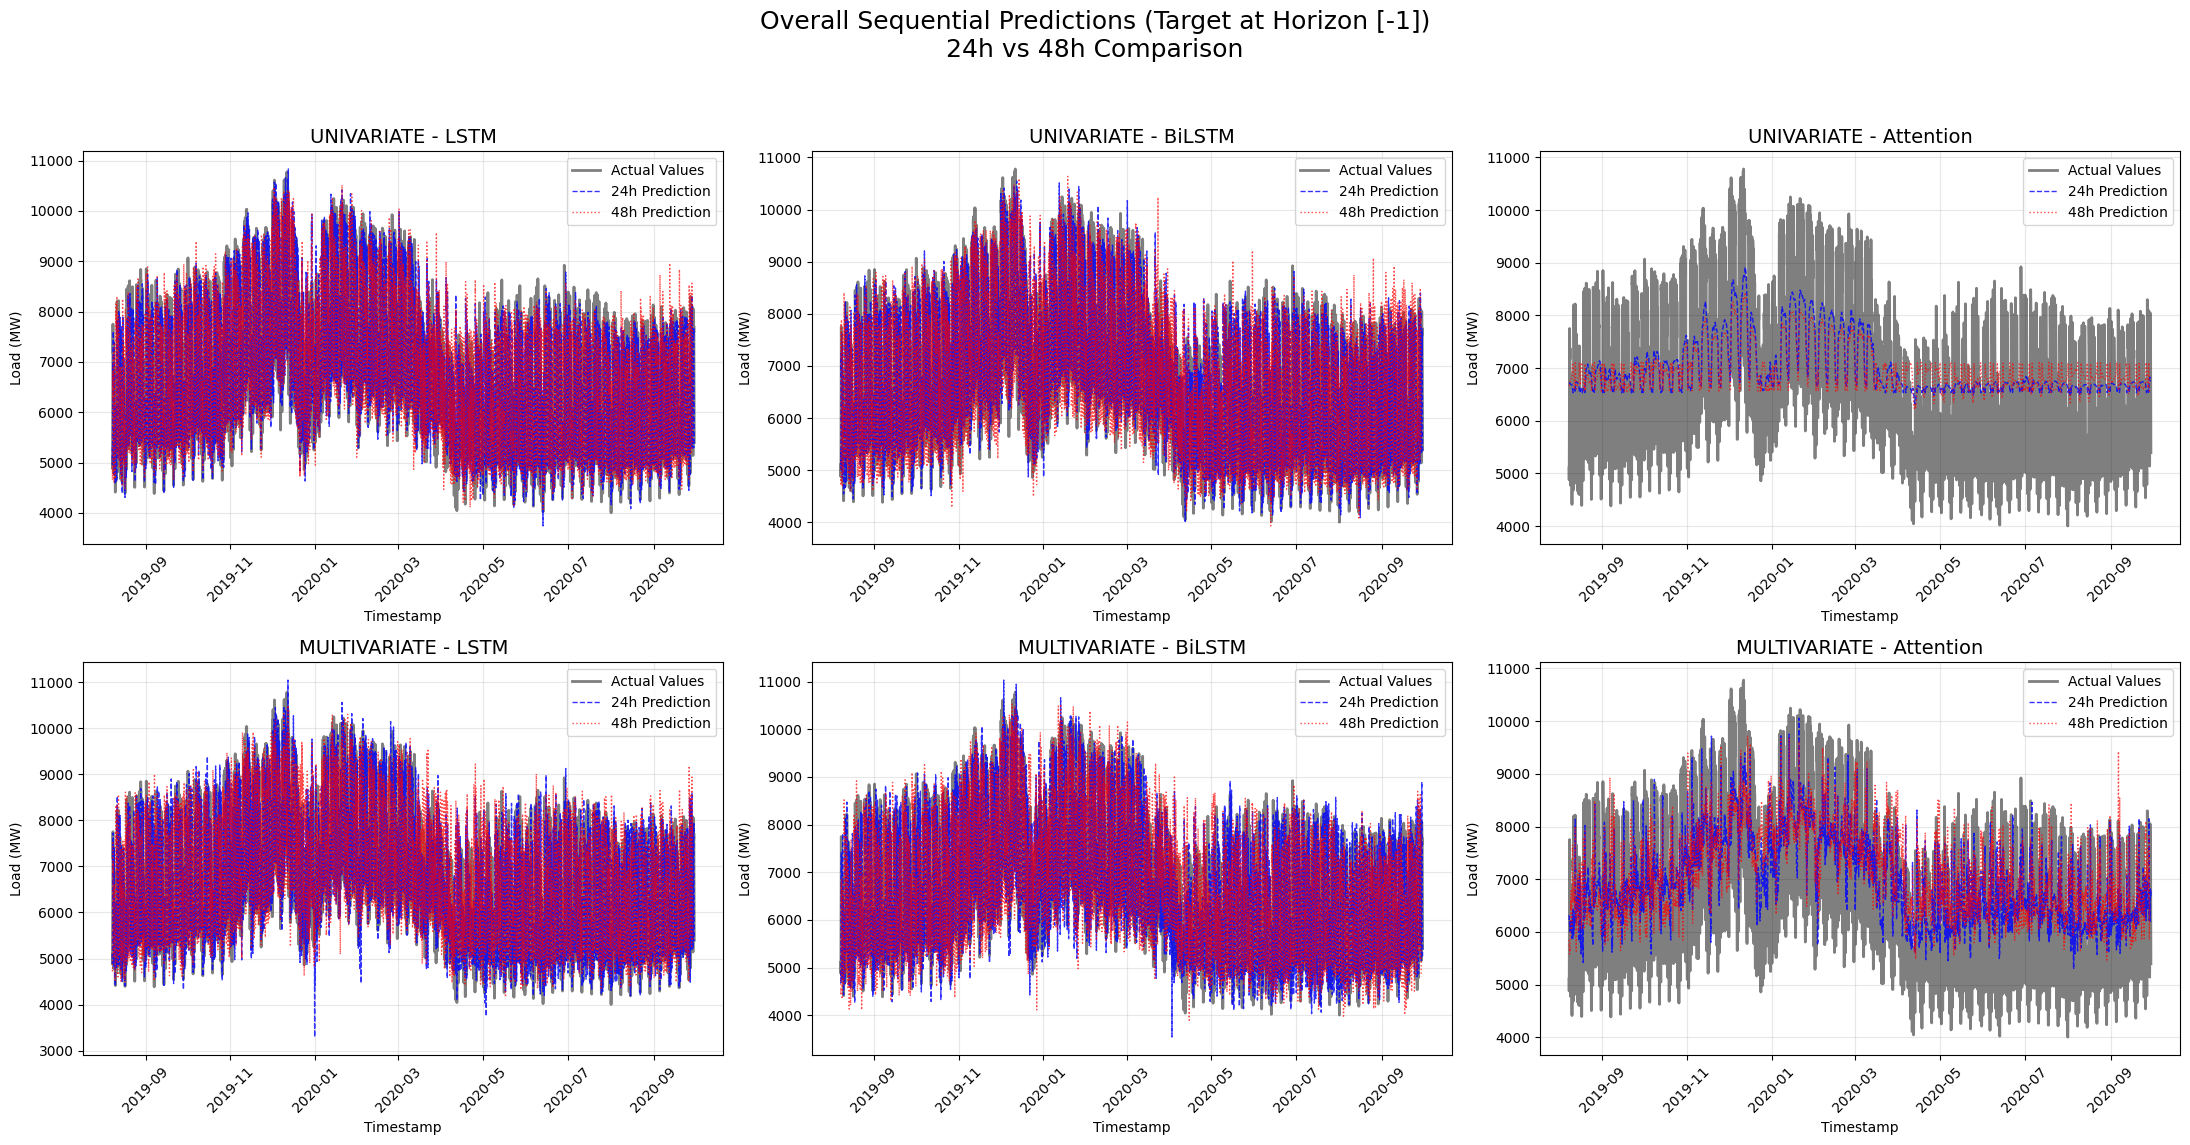

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import re

def parse_array_string(s):
    if not isinstance(s, str):
        return s
    s_clean = re.sub(r'np\.float\d+\(', '', s)
    s_clean = s_clean.replace(')', '')
    s_clean = s_clean.strip('[]')
    s_clean = re.sub(r'[,]+', ' ', s_clean)
    s_clean = re.sub(r'\s+', ' ', s_clean).strip()
    if not s_clean:
        return []
    return [float(x) for x in s_clean.split(' ')]

feature_types = ['UNIVARIATE', 'MULTIVARIATE']
models_list = ['LSTM', 'BiLSTM', 'Attention']

# Buat figure untuk 2 tipe fitur x 3 model = 6 axes (2 baris x 3 kolom)
fig, axes = plt.subplots(len(feature_types), len(models_list), figsize=(22, 12))
fig.suptitle('Overall Sequential Predictions (Target at Horizon [-1])\n24h vs 48h Comparison', fontsize=18)

for i, ft in enumerate(feature_types):
    for j, model_name in enumerate(models_list):
        ax = axes[i, j]
        
        # --- LOAD DATA 24h ---
        csv_24h = f'KAGGLE_RESULTS_FIX/{ft}/24h/results/{model_name}_yj_denormalized.csv'
        if os.path.exists(csv_24h):
            df_24h = pd.read_csv(csv_24h)
            # Revert to original chronological sequence using DATE_OF_DATA_POINT
            df_24h['DATE_OF_DATA_POINT'] = pd.to_datetime(df_24h['DATE_OF_DATA_POINT'])
            df_24h = df_24h.sort_values(by='DATE_OF_DATA_POINT').reset_index(drop=True)
            
            dates_24h = df_24h['DATE_OF_DATA_POINT']
            
            # Ambil element indeks terakhir (index +h atau prediksi untuk target horizon)
            actual_24h = [parse_array_string(s)[-1] for s in df_24h['ACTUAL_VALUE_HORIZON_DENORM']]
            pred_24h = [parse_array_string(s)[-1] for s in df_24h['PREDICTED_VALUE_HORIZON_DENORM']]
            
            # Plot data asli (ground truth)
            ax.plot(dates_24h, actual_24h, label='Actual Values', color='black', alpha=0.5, linewidth=2)
            # Plot prediksi horizon 24h
            ax.plot(dates_24h, pred_24h, label='24h Prediction', color='blue', alpha=0.8, linewidth=1, linestyle='--')
        
        # --- LOAD DATA 48h ---
        csv_48h = f'KAGGLE_RESULTS_FIX/{ft}/48h/results/{model_name}_yj_denormalized.csv'
        if os.path.exists(csv_48h):
            df_48h = pd.read_csv(csv_48h)
            # Revert to original chronological sequence using DATE_OF_DATA_POINT
            df_48h['DATE_OF_DATA_POINT'] = pd.to_datetime(df_48h['DATE_OF_DATA_POINT'])
            df_48h = df_48h.sort_values(by='DATE_OF_DATA_POINT').reset_index(drop=True)
            
            dates_48h = df_48h['DATE_OF_DATA_POINT']
            
            # Ambil element indeks terakhir prediksi horizon 48h
            pred_48h = [parse_array_string(s)[-1] for s in df_48h['PREDICTED_VALUE_HORIZON_DENORM']]
            ax.plot(dates_48h, pred_48h, label='48h Prediction', color='red', alpha=0.7, linewidth=1, linestyle=':')
            
        # Percantik plot subplot
        ax.set_title(f'{ft} - {model_name}', fontsize=14)
        ax.set_xlabel('Timestamp')
        ax.set_ylabel('Load (MW)')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [13]:
X_train_yj = np.load('KAGGLE_RESULTS_FIX/UNIVARIATE/48h/dataset_ready/X_train_yj.npy')
y_train_yj = np.load('KAGGLE_RESULTS_FIX/UNIVARIATE/48h/dataset_ready/y_train_yj.npy')

X_val_yj = np.load('KAGGLE_RESULTS_FIX/UNIVARIATE/48h/dataset_ready/X_val_yj.npy')
y_val_yj = np.load('KAGGLE_RESULTS_FIX/UNIVARIATE/48h/dataset_ready/y_val_yj.npy')

y_test_yj = np.load('KAGGLE_RESULTS_FIX/UNIVARIATE/48h/dataset_ready/y_test_yj.npy')
X_test_yj = np.load('KAGGLE_RESULTS_FIX/UNIVARIATE/48h/dataset_ready/X_test_yj.npy')

print(f"x_train_yj.shape: {X_train_yj.shape}")
print(f"y_train_yj.shape: {y_train_yj.shape}")

print(f"x_val_yj.shape: {X_val_yj.shape}")
print(f"y_val_yj.shape: {y_val_yj.shape}")

print(f"x_test_yj.shape: {X_test_yj.shape}")
print(f"y_test_yj.shape: {y_test_yj.shape}")

x_train_yj.shape: (32236, 24, 1)
y_train_yj.shape: (32236, 48)
x_val_yj.shape: (8060, 24, 1)
y_val_yj.shape: (8060, 48)
x_test_yj.shape: (10033, 24, 1)
y_test_yj.shape: (10033, 48)


In [14]:
X_train = np.load('KAGGLE_RESULTS/UNIVARIATE/6h/dataset_ready/X_train.npy')
y_train = np.load('KAGGLE_RESULTS/UNIVARIATE/6h/dataset_ready/y_train.npy')

X_val = np.load('KAGGLE_RESULTS/UNIVARIATE/6h/dataset_ready/X_val.npy')
y_val = np.load('KAGGLE_RESULTS/UNIVARIATE/6h/dataset_ready/y_val.npy')

y_test = np.load('KAGGLE_RESULTS/UNIVARIATE/6h/dataset_ready/y_test.npy')
X_test = np.load('KAGGLE_RESULTS/UNIVARIATE/6h/dataset_ready/X_test.npy')

print(f"x_train.shape: {X_train.shape}")
print(f"y_train.shape: {y_train.shape}")

print(f"x_val.shape: {X_val.shape}")
print(f"y_val.shape: {y_val.shape}")

print(f"x_test.shape: {X_test.shape}")
print(f"y_test.shape: {y_test.shape}")

x_train.shape: (40296, 24, 1)
y_train.shape: (40296, 6)
x_val.shape: (5037, 24, 1)
y_val.shape: (5037, 6)
x_test.shape: (5038, 24, 1)
y_test.shape: (5038, 6)
